# Domaći zadatak – Analiza sentimenta filmskih recenzija (IMDB)
## Poglavlje 1: Eksploratorna analiza podataka (EDA)

**Predmet:** Veštačka inteligencija sa primenama  
**Tip problema:** binarna klasifikacija teksta (Transformer)  
**Skup podataka:** IMDB – 50.000 filmskih recenzija (25.000 trening + 25.000 test), ravnomerno podeljenih na pozitivne (1) i negativne (0).

Cilj ovog notebooka je da se skup podataka učita, proveri (nedostajuće/nevalidne vrednosti),
i opiše osnovnom deskriptivnom statistikom i vizuelizacijama. Zaključci EDA koriste se za
donošenje odluka u pripremi podataka (npr. izbor dužine sekvence `max_len` i veličine vokabulara `num_words`).

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Omogućavamo uvoz iz paketa src (notebook se pokreće iz foldera notebooks/)
sys.path.append(os.path.abspath('..'))
from src import data as D

sns.set_theme(style='whitegrid')
FIG = os.path.abspath('../results/figures')
os.makedirs(FIG, exist_ok=True)
np.random.seed(42)
print('OK – biblioteke učitane')

OK – biblioteke učitane


## 1. Učitavanje podataka
Koristimo zvaničnu, već tokenizovanu verziju IMDB skupa. Svaka recenzija je niz celih
brojeva – rangova reči po učestalosti (1 = najčešća reč). Reči možemo vratiti u tekst
pomoću inverznog rečnika (rang → reč).

In [2]:
x_train, y_train, x_test, y_test = D.load_raw()
word_index = D.load_word_index()
reverse_index = D.build_reverse_index(word_index)

print('Trening recenzija:', len(x_train))
print('Test recenzija:   ', len(x_test))
print('Veličina rečnika: ', len(word_index), 'jedinstvenih reči')
print()
print('Primer dekodirane recenzije (labela =', y_train[0], '):')
print(D.decode_ranks(x_train[0][:60], reverse_index), '...')

C:\Users\ZVERKO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Trening recenzija: 25000
Test recenzija:    25000
Veličina rečnika:  88584 jedinstvenih reči

Primer dekodirane recenzije (labela = 1 ):
bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my 35 years in the teaching profession lead me to believe that bromwell high's satire is much closer to reality than is teachers the scramble to survive financially the insightful students who can see right through their pathetic ...


## 2. Provera kvaliteta podataka (nedostajuće / nevalidne vrednosti)
Proveravamo da li postoje prazne recenzije, nedostajuće labele, labele van skupa {0,1}
i da li ima duplikata. Kod ovako pripremljenog skupa ne očekujemo nedostajuće vrednosti,
ali proveru moramo eksplicitno prikazati.

In [3]:
lengths_train = np.array([len(s) for s in x_train])
empty = int((lengths_train == 0).sum())
labels_ok = set(np.unique(y_train)).issubset({0, 1})
nan_labels = int(np.isnan(y_train.astype(float)).sum())

report = pd.DataFrame({
    'Provera': ['Prazne recenzije', 'Nedostajuće labele (NaN)',
                'Labele van {0,1}', 'Min dužina', 'Max dužina'],
    'Vrednost': [empty, nan_labels, 0 if labels_ok else 1,
                 int(lengths_train.min()), int(lengths_train.max())]
})
print(report.to_string(index=False))
print('\nZaključak: skup je kompletan (nema nedostajućih vrednosti), labele su ispravne.')

                 Provera  Vrednost
        Prazne recenzije         0
Nedostajuće labele (NaN)         0
        Labele van {0,1}         0
              Min dužina        10
              Max dužina      2493

Zaključak: skup je kompletan (nema nedostajućih vrednosti), labele su ispravne.


## 3. Balans klasa
Uravnotežen skup je važan: ako su klase ravnomerne, tačnost (accuracy) je pouzdana metrika,
a osnovna linija slučajnog pogađanja iznosi 50%.

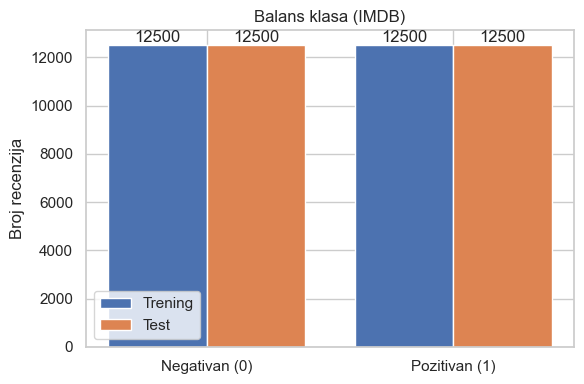

Trening: {'Negativan (0)': np.int64(12500), 'Pozitivan (1)': np.int64(12500)}


In [4]:
counts_train = np.bincount(y_train)
counts_test = np.bincount(y_test)
labels = ['Negativan (0)', 'Pozitivan (1)']

fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(2)
ax.bar(x-0.2, counts_train, width=0.4, label='Trening')
ax.bar(x+0.2, counts_test, width=0.4, label='Test')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Broj recenzija'); ax.set_title('Balans klasa (IMDB)')
ax.legend()
for i,v in enumerate(counts_train): ax.text(i-0.2, v+150, str(v), ha='center')
for i,v in enumerate(counts_test):  ax.text(i+0.2, v+150, str(v), ha='center')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'eda_class_balance.png'), dpi=130); plt.show()
print('Trening:', dict(zip(labels, counts_train)))

## 4. Distribucija dužine recenzija
Dužina recenzije (broj reči) direktno utiče na izbor parametra `max_len` (dužina na koju
skraćujemo/dopunjujemo sve sekvence). Gledamo histogram i percentile.

Prosečna dužina: 237.7 reči
Medijana: 177 | 75%: 290 | 90%: 466 | 95%: 609 | 99%: 925


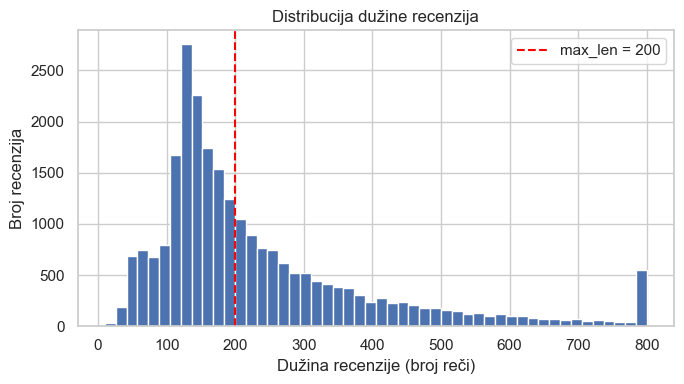

Uz max_len=200 potpuno je obuhvaćeno 57.6% recenzija.


In [5]:
pct = np.percentile(lengths_train, [50, 75, 90, 95, 99])
print('Prosečna dužina: %.1f reči' % lengths_train.mean())
print('Medijana: %d | 75%%: %d | 90%%: %d | 95%%: %d | 99%%: %d' % (pct[0],pct[1],pct[2],pct[3],pct[4]))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.clip(lengths_train, 0, 800), bins=50, color='#4c72b0')
ax.axvline(200, color='red', linestyle='--', label='max_len = 200')
ax.set_xlabel('Dužina recenzije (broj reči)'); ax.set_ylabel('Broj recenzija')
ax.set_title('Distribucija dužine recenzija'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'eda_length_hist.png'), dpi=130); plt.show()
cover = (lengths_train <= 200).mean()*100
print('Uz max_len=200 potpuno je obuhvaćeno %.1f%% recenzija.' % cover)

## 5. Odnos dužine recenzije i sentimenta
Proveravamo da li postoji povezanost između dužine recenzije i klase (npr. da li su
negativne recenzije sistematski duže). Koristimo point-biserial korelaciju.

Point-biserial korelacija (labela vs dužina): r = 0.016 (p = 0.0107)


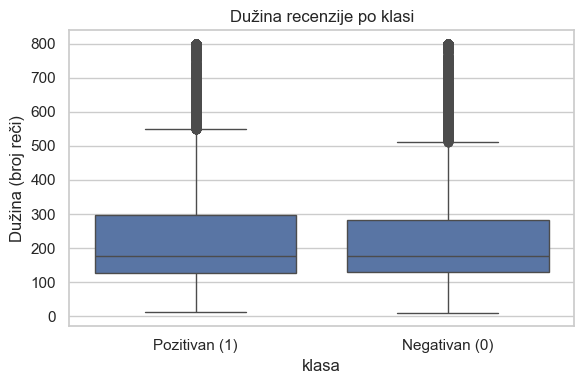

Korelacija je vrlo slaba -> dužina nije jak prediktor sentimenta.


In [6]:
from scipy.stats import pointbiserialr
r, p = pointbiserialr(y_train, lengths_train)
print('Point-biserial korelacija (labela vs dužina): r = %.3f (p = %.3g)' % (r, p))

df = pd.DataFrame({'duzina': np.clip(lengths_train,0,800), 'klasa':[labels[i] for i in y_train]})
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='klasa', y='duzina', ax=ax)
ax.set_title('Dužina recenzije po klasi'); ax.set_ylabel('Dužina (broj reči)')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'eda_length_by_class.png'), dpi=130); plt.show()
print('Korelacija je vrlo slaba -> dužina nije jak prediktor sentimenta.')

## 6. Najčešće reči i analiza OOV (van vokabulara)
Ograničavamo vokabular na `num_words` najčešćih reči. Reči van tog opsega tretiraju se kao
OOV (Out Of Vocabulary). Proveravamo koliki procenat tokena postaje OOV pri num_words=20000.

OOV udeo pri num_words=20000: 2.86%


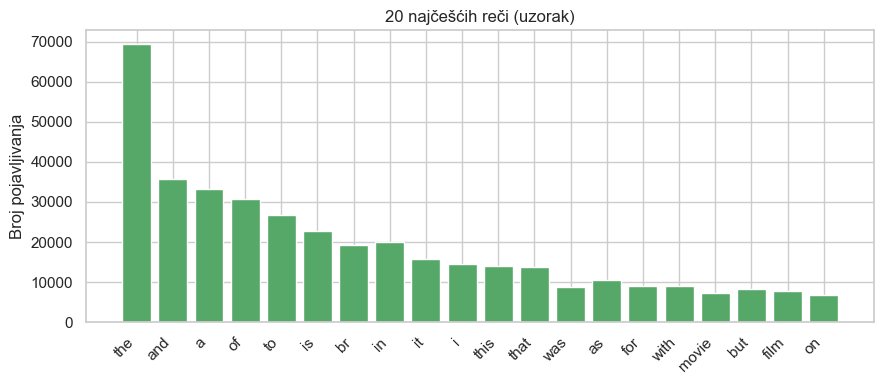

In [7]:
num_words = 20000
# Udeo OOV tokena na uzorku od 5000 recenzija
sample = x_train[:5000]
tot = sum(len(s) for s in sample)
oov = sum(1 for s in sample for t in s if t >= num_words)
print('OOV udeo pri num_words=%d: %.2f%%' % (num_words, 100*oov/tot))

# 20 najčešćih reči (rang 1..20)
top_words = [reverse_index[i] for i in range(1,21)]
# frekvencije procenjujemo brojanjem na uzorku
from collections import Counter
c = Counter(t for s in sample for t in s if t < 21)
freq = [c.get(i,0) for i in range(1,21)]
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(top_words, freq, color='#55a868')
ax.set_title('20 najčešćih reči (uzorak)'); ax.set_ylabel('Broj pojavljivanja')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'eda_top_words.png'), dpi=130); plt.show()

## 7. Word cloud – pozitivne vs negativne recenzije
Da bismo intuitivno videli razliku između klasa, prikazujemo oblake reči za pozitivne i
negativne recenzije (nakon uklanjanja čestih zaustavnih reči).

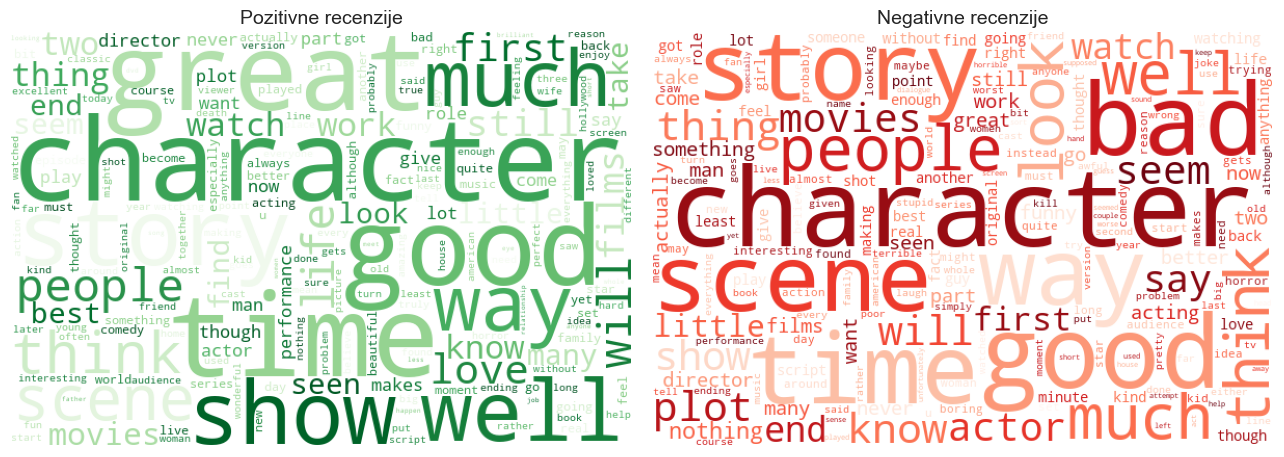

In [8]:
from wordcloud import WordCloud, STOPWORDS
stop = set(STOPWORDS) | {'br','movie','film','one','make','made','see','even','get','really'}

def class_text(x, y, cls, n=4000):
    idx = np.where(y==cls)[0][:n]
    words = []
    for i in idx:
        words += [reverse_index.get(t,'') for t in x[i] if t < 20000]
    return ' '.join(w for w in words if w and w not in stop)

pos_text = class_text(x_train, y_train, 1)
neg_text = class_text(x_train, y_train, 0)
fig, axes = plt.subplots(1,2, figsize=(13,5))
for ax, txt, title, cmap in [(axes[0],pos_text,'Pozitivne recenzije','Greens'),
                             (axes[1],neg_text,'Negativne recenzije','Reds')]:
    wc = WordCloud(width=600, height=400, background_color='white', colormap=cmap, stopwords=stop).generate(txt)
    ax.imshow(wc); ax.axis('off'); ax.set_title(title, fontsize=14)
plt.tight_layout(); plt.savefig(os.path.join(FIG,'eda_wordclouds.png'), dpi=130); plt.show()

## 8. Zaključci eksploratorne analize
- Skup je **kompletan i uravnotežen** (12.500 : 12.500 po klasi u treningu), pa je *accuracy* pouzdana metrika, a osnovna linija je 50%.
- Dužina recenzija je vrlo promenljiva; **`max_len = 200`** obuhvata veliku većinu sadržaja uz razuman utrošak memorije i vremena treniranja.
- Dužina recenzije **slabo** korelira sa sentimentom, pa se ne oslanjamo na nju kao poseban atribut.
- Ograničavanje vokabulara na **`num_words = 20000`** zadržava skoro sve tokene (nizak OOV udeo), a smanjuje veličinu embedding tabele.
- Word cloud jasno pokazuje razliku u rečniku pozitivnih i negativnih recenzija, što opravdava pristup zasnovan na rečima.

Ovi zaključci direktno definišu parametre pripreme podataka u `src/preprocessing.py` i `configs/experiments.yaml`.